# TSN Scheduling Algorithms - Traffic Analysis
**Objective:** To analyze the Inter-Arrival Time, Max Delay Spikes, and Jitter for Video, Audio, and Text traffic under various TSN queuing disciplines (TAPRIO, CBS).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore') # To ignore minor pandas warnings

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


### Creating a Reusable Analysis Function
We will create a function `analyze_tsn_traffic` that reads a CSV file, calculates the Inter-Arrival Times, plots the dotted scatter graph, and outputs the statistics table (Mean, Max Spike, Jitter).

In [2]:
def analyze_tsn_traffic(file_path, algorithm_name):
    print(f"--- Analyzing: {algorithm_name} ---")
    
    # 1. Read Data
    df = pd.read_csv(file_path)
    df['arrival_time'] = pd.to_datetime(df['arrival_time'])
    
    # Sort data by payload type and arrival time to calculate exact gaps
    df = df.sort_values(by=['payload', 'arrival_time'])
    
    # 2. Calculate Inter-Arrival Time (The Gap)
    df['inter_arrival_ms'] = df.groupby('payload')['arrival_time'].diff().dt.total_seconds() * 1000
    
    # 3. Plotting the Graph
    plt.figure(figsize=(12, 5))
    payload_colors = {'video': 'red', 'audio': 'blue', 'text': 'green'}
    expected_gaps = {'video': 20, 'audio': 10, 'text': 5}
    
    for payload in ['video', 'audio', 'text']:
        subset = df[df['payload'] == payload].copy()
        subset['seq'] = range(len(subset)) # Sequence number for X-axis
        
        plt.plot(subset['seq'], subset['inter_arrival_ms'], 
                 marker='.', linestyle='none', color=payload_colors[payload], alpha=0.6,
                 label=f'{payload.capitalize()} (Expected: {expected_gaps[payload]}ms)')
    
    plt.title(f'Inter-Arrival Times at Receiver ({algorithm_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Packet Sequence Number', fontsize=12)
    plt.ylabel('Inter-Arrival Gap / Delay (ms)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 4. Calculating and Printing Statistics
    stats = df.groupby('payload')['inter_arrival_ms'].agg(
        Total_Packets='count',
        Avg_Gap_ms='mean',
        Min_Gap_ms='min',
        Max_Delay_Spike_ms='max',
        Jitter_Std_Dev='std'
    ).round(2)
    
    print(stats)
    print("\n" + "="*80 + "\n")
    return stats

--- Analyzing: Baseline (No QoS / Default Queues) ---


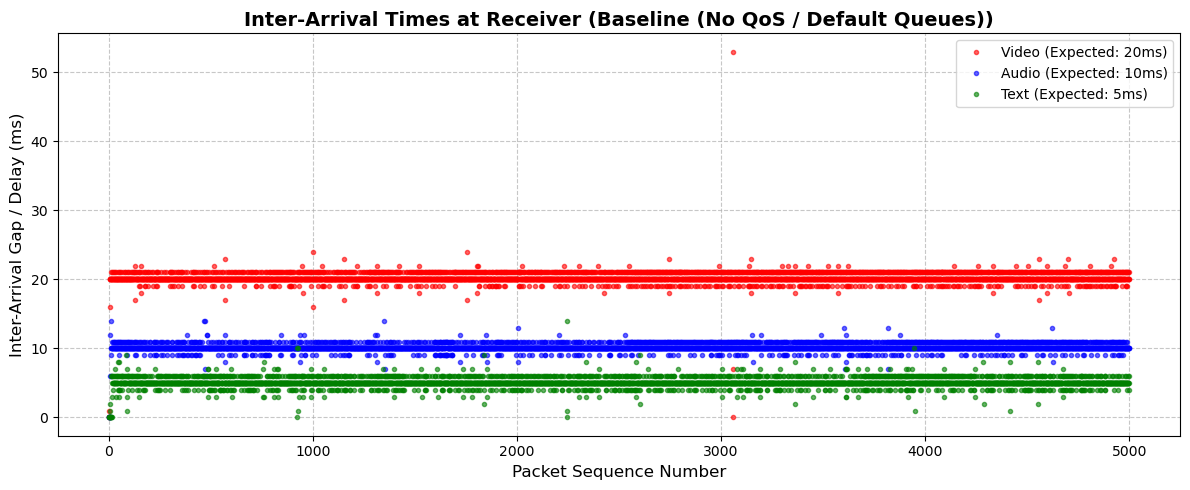

         Total_Packets  Avg_Gap_ms  Min_Gap_ms  Max_Delay_Spike_ms  \
payload                                                              
audio             4999       10.13         0.0                14.0   
text              4999        5.08         0.0                14.0   
video             4999       20.19         0.0                53.0   

         Jitter_Std_Dev  
payload                  
audio              0.63  
text               0.67  
video              0.95  




In [3]:
# 1. Baseline (No QoS)
stats_baseline = analyze_tsn_traffic('NOQoS_traffic_log.csv', 'Baseline (No QoS / Default Queues)')

--- Analyzing: Round Robin TAPRIO (1ms Equal Gates) ---


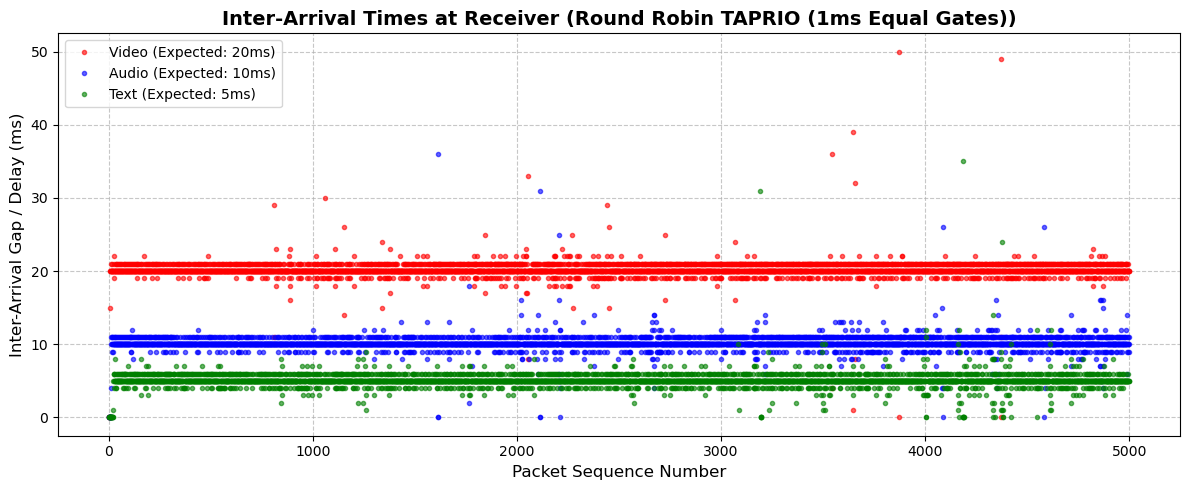

         Total_Packets  Avg_Gap_ms  Min_Gap_ms  Max_Delay_Spike_ms  \
payload                                                              
audio             4999       10.11         0.0                36.0   
text              4999        5.07         0.0                35.0   
video             4999       20.18         0.0                50.0   

         Jitter_Std_Dev  
payload                  
audio              1.12  
text               1.06  
video              1.36  




In [4]:
# 2. Round Robin TAPRIO (Equal 1ms gates)
stats_rr = analyze_tsn_traffic('RRTAS_traffic_log.csv', 'Round Robin TAPRIO (1ms Equal Gates)')

--- Analyzing: Strict Priority TAPRIO (Video 2ms, Text 1ms) ---


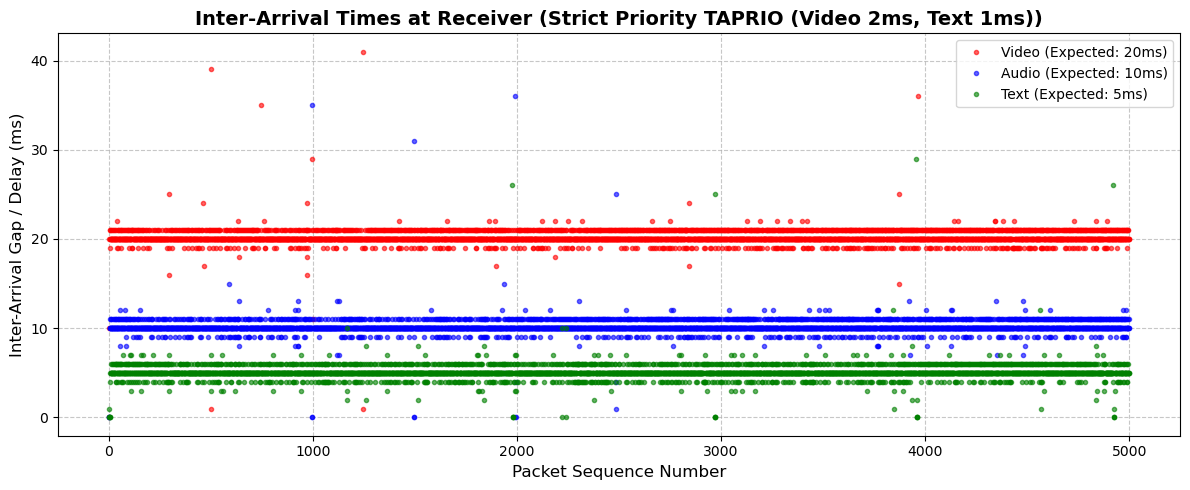

         Total_Packets  Avg_Gap_ms  Min_Gap_ms  Max_Delay_Spike_ms  \
payload                                                              
audio             4999       10.13         0.0                36.0   
text              4999        5.09         0.0                29.0   
video             4999       20.20         0.0                41.0   

         Jitter_Std_Dev  
payload                  
audio              0.96  
text               0.92  
video              0.98  




In [5]:
# 3. Strict Priority (Time-Weighted)
stats_sp = analyze_tsn_traffic('SP_traffic_log.csv', 'Strict Priority TAPRIO (Video 2ms, Text 1ms)')

--- Analyzing: EDF Approximation (Interleaved Gates) ---


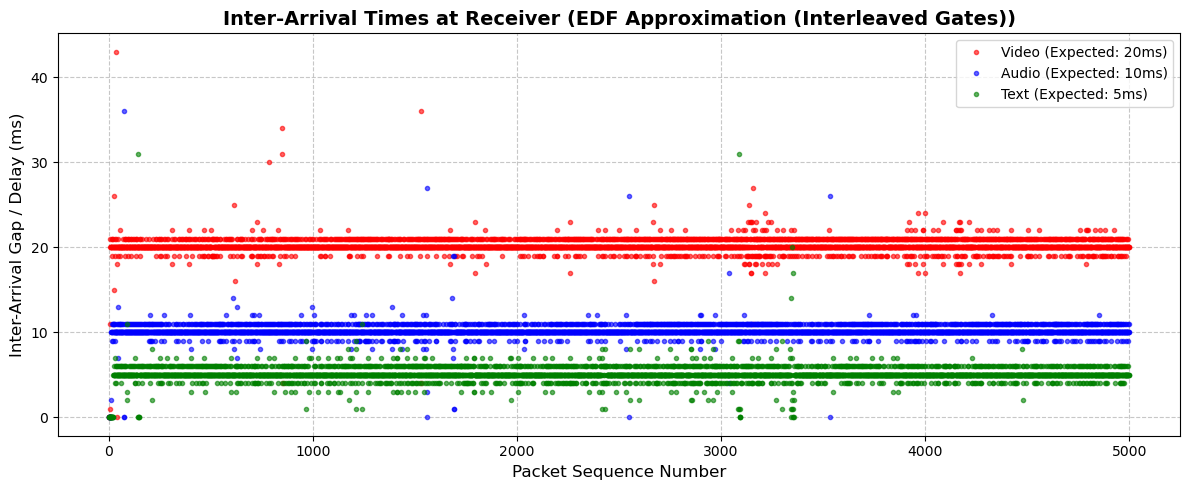

         Total_Packets  Avg_Gap_ms  Min_Gap_ms  Max_Delay_Spike_ms  \
payload                                                              
audio             4999       10.13         0.0                36.0   
text              4999        5.07         0.0                31.0   
video             4999       20.16         0.0                43.0   

         Jitter_Std_Dev  
payload                  
audio              0.99  
text               1.00  
video              1.15  




In [6]:
# 4. EDF Approximation
stats_edf = analyze_tsn_traffic('EDF_traffic_log.csv', 'EDF Approximation (Interleaved Gates)')

--- Analyzing: CBS (Credit-Based Shaper / 802.1Qav) ---


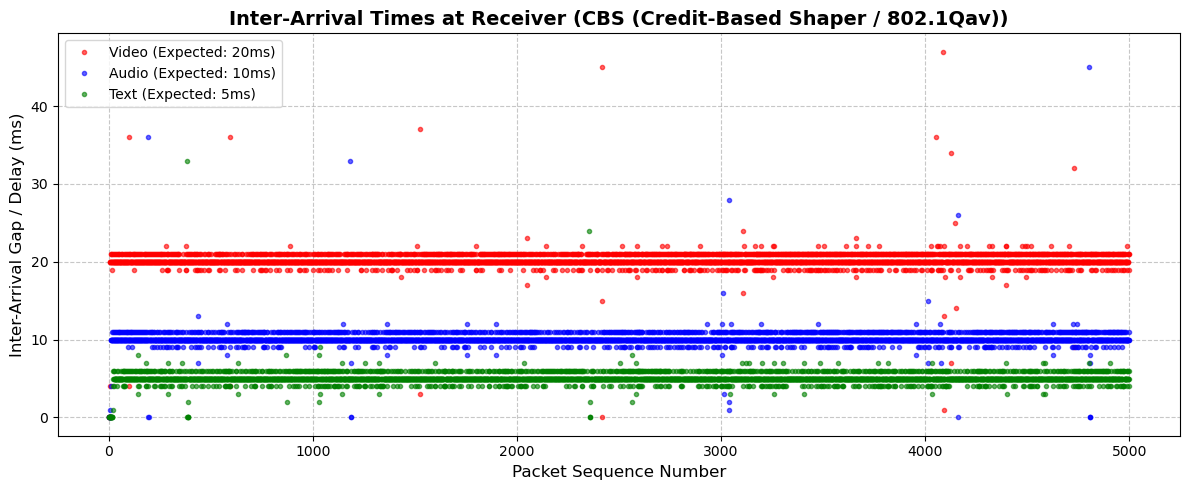

         Total_Packets  Avg_Gap_ms  Min_Gap_ms  Max_Delay_Spike_ms  \
payload                                                              
audio             4999       10.11         0.0                45.0   
text              4999        5.07         0.0                33.0   
video             4999       20.18         0.0                47.0   

         Jitter_Std_Dev  
payload                  
audio              1.12  
text               0.80  
video              1.30  




In [7]:
# 5. CBS (Credit-Based Shaper)
stats_cbs = analyze_tsn_traffic('CBS_traffic_log.csv', 'CBS (Credit-Based Shaper / 802.1Qav)')

### Final Comparison: Jitter Analysis
This graph proves how Strict Priority effectively minimized the Jitter for Video traffic compared to other algorithms.

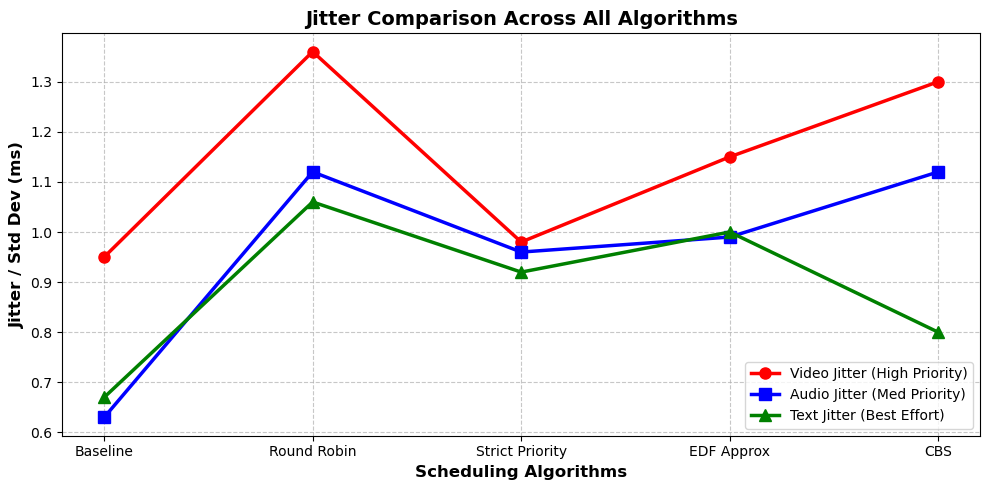

In [8]:
algorithms = ['Baseline', 'Round Robin', 'Strict Priority', 'EDF Approx', 'CBS']

# but putting the variables manually for a clean comparison graph)
video_jitter = [stats_baseline.loc['video', 'Jitter_Std_Dev'], stats_rr.loc['video', 'Jitter_Std_Dev'], 
                stats_sp.loc['video', 'Jitter_Std_Dev'], stats_edf.loc['video', 'Jitter_Std_Dev'], 
                stats_cbs.loc['video', 'Jitter_Std_Dev']]

audio_jitter = [stats_baseline.loc['audio', 'Jitter_Std_Dev'], stats_rr.loc['audio', 'Jitter_Std_Dev'], 
                stats_sp.loc['audio', 'Jitter_Std_Dev'], stats_edf.loc['audio', 'Jitter_Std_Dev'], 
                stats_cbs.loc['audio', 'Jitter_Std_Dev']]

text_jitter  = [stats_baseline.loc['text', 'Jitter_Std_Dev'], stats_rr.loc['text', 'Jitter_Std_Dev'], 
                stats_sp.loc['text', 'Jitter_Std_Dev'], stats_edf.loc['text', 'Jitter_Std_Dev'], 
                stats_cbs.loc['text', 'Jitter_Std_Dev']]

plt.figure(figsize=(10, 5))
plt.plot(algorithms, video_jitter, marker='o', color='red', label='Video Jitter (High Priority)', linewidth=2.5, markersize=8)
plt.plot(algorithms, audio_jitter, marker='s', color='blue', label='Audio Jitter (Med Priority)', linewidth=2.5, markersize=8)
plt.plot(algorithms, text_jitter, marker='^', color='green', label='Text Jitter (Best Effort)', linewidth=2.5, markersize=8)

plt.title('Jitter Comparison Across All Algorithms', fontsize=14, fontweight='bold')
plt.xlabel('Scheduling Algorithms', fontsize=12, fontweight='bold')
plt.ylabel('Jitter / Std Dev (ms)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()